## 3 Agent setup with LangGraph

### Why we avoid first-speaker anchoring bias

Large language models can show **anchoring bias**: the first argument presented may disproportionately influence later evaluation. In a debate workflow, if the moderator sees only one side first, it can skew routing and judgment.

To reduce this bias, this graph runs a **coin toss** to randomize who speaks first (**for** or **against**), then forces one opening response from both debaters before the moderator performs its first evaluation. The moderator is also required to request **at least one follow-up** before ending, so there is always a rebuttal-style debate turn.

In this sections we will add 3 agents where one is a moderator agent and 2 agents are participants of a debate team. One takes the "for" stance and other takes the "against" stance. We will have the moderator as an evaluator agent.

**Flow graph**

```text
                 +--------------------+
                 | Agent "For" Topic  |
                 +----------+---------+
                            |
+-------------+             v             +----------------------+
|  Moderator  +----------> +-------------+  Moderator evaluates  +----> End
+------+------+             ^             +----------+-----------+
       |                    |                        |
       |         +----------+---------+              |
       +-------> | Agent "Against"    | <------------+
                 | Topic               |
                 +---------------------+

If more data is needed, moderator reinvokes both agents with a follow-up question.
```



### Step 1: Imports and model setup

This cell imports dependencies, loads environment variables, configures the moderator call limit, and initializes the LLM used by all nodes.


In [8]:
from operator import add
from typing import Annotated, Literal
import os
import random

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command
from pydantic import BaseModel

load_dotenv()

MAX_MODERATOR_CALLS = 3

# Use model from env and normalize OpenAI-compatible Gemini model naming.
raw_model_name = os.getenv("GEMINI_MODEL", "gemini-2.5-flash")
model_name = raw_model_name.replace("models/", "", 1)

llm = init_chat_model(
    model=model_name,
    model_provider="google_genai",
    api_key=os.getenv("GEMINI_API_KEY"),
)

### Step 2: State and structured outputs

This cell defines:
- `ModeratorResponse`: strict schema for moderator routing decisions.
- `DebateState`: shared graph state with response history, follow-up question, and moderation counters.

Using typed state keeps updates explicit and predictable across nodes.

In [9]:
from typing_extensions import TypedDict


class ModeratorResponse(BaseModel):
    decision: Literal["for_agent", "against_agent", "end"]
    follow_up_question: str = ""
    winner: Literal["for_agent", "against_agent", "tie", "undecided"] = "undecided"
    winner_rationale: str = ""


class FinalVerdictResponse(BaseModel):
    """Structured verdict when debate must end — never undecided."""

    winner: Literal["for_agent", "against_agent", "tie"]
    winner_rationale: str = ""


class DebateState(TypedDict):
    topic: str
    for_agent_response: Annotated[list[str], add]
    against_agent_response: Annotated[list[str], add]
    follow_up_question: str
    moderator_calls: int
    opening_first_speaker: Literal["for_agent", "against_agent"]
    winner: Literal["for_agent", "against_agent", "tie", "undecided"]
    winner_rationale: str

### Step 3: Node logic

This cell defines all node functions:
- `coinToss`: randomizes first speaker to reduce first-speaker bias.
- `forAgent` / `againstAgent`: generate stance responses and rebut opponent points after opening round.
- `moderator`: routes the debate, enforces max moderation calls, guarantees at least one follow-up turn before ending, and when the call limit forces an end, requires a final **for_agent / against_agent / tie** verdict (never `undecided`) via `FinalVerdictResponse`.

In [10]:
def coinToss(state: DebateState) -> Command[Literal["for_agent", "against_agent"]]:
    first_speaker = random.choice(["for_agent", "against_agent"])
    return Command(
        goto=first_speaker,
        update={"opening_first_speaker": first_speaker},
    )


def forAgent(state: DebateState) -> Command[Literal["against_agent", "moderator"]]:
    user_prompt = state["follow_up_question"] or "What is your stance on the topic?"

    is_opening_round = (
        len(state["for_agent_response"]) == 0 or len(state["against_agent_response"]) == 0
    ) and state["moderator_calls"] == 0

    system_content = f"You are a debater FOR the topic: {state['topic']}"
    if not is_opening_round and state["against_agent_response"]:
        system_content += (
            "\nOpponent's latest argument (AGAINST): "
            f"{state['against_agent_response'][-1]}\n"
            "Address and rebut this argument in your response."
        )

    response = llm.invoke(
        [
            {"role": "system", "content": system_content},
            {"role": "user", "content": user_prompt},
        ]
    )

    first_round_needs_against = (
        len(state["for_agent_response"]) == 0 and len(state["against_agent_response"]) == 0
    ) or (len(state["against_agent_response"]) == 0 and state["moderator_calls"] == 0)
    next_node = "against_agent" if first_round_needs_against else "moderator"

    return Command(
        goto=next_node,
        update={
            "for_agent_response": [response.content],
            "follow_up_question": "",
        },
    )


def againstAgent(state: DebateState) -> Command[Literal["for_agent", "moderator"]]:
    user_prompt = state["follow_up_question"] or "What is your stance on the topic?"

    is_opening_round = (
        len(state["for_agent_response"]) == 0 or len(state["against_agent_response"]) == 0
    ) and state["moderator_calls"] == 0

    system_content = f"You are a debater AGAINST the topic: {state['topic']}"
    if not is_opening_round and state["for_agent_response"]:
        system_content += (
            "\nOpponent's latest argument (FOR): "
            f"{state['for_agent_response'][-1]}\n"
            "Address and rebut this argument in your response."
        )

    response = llm.invoke(
        [
            {"role": "system", "content": system_content},
            {"role": "user", "content": user_prompt},
        ]
    )

    first_round_needs_for = (
        len(state["for_agent_response"]) == 0 and len(state["against_agent_response"]) == 0
    ) or (len(state["for_agent_response"]) == 0 and state["moderator_calls"] == 0)
    next_node = "for_agent" if first_round_needs_for else "moderator"

    return Command(
        goto=next_node,
        update={
            "against_agent_response": [response.content],
            "follow_up_question": "",
        },
    )


def moderator(state: DebateState) -> Command:
    calls = state["moderator_calls"] + 1

    moderator_llm = llm.with_structured_output(ModeratorResponse)
    decision = moderator_llm.invoke(
        [
            {
                "role": "system",
                "content": (
                    f"You are a debate moderator for topic: {state['topic']}. "
                    f"FOR responses: {state['for_agent_response']}. "
                    f"AGAINST responses: {state['against_agent_response']}. "
                    "Choose one decision: for_agent, against_agent, or end. "
                    "If you choose end, you must also set winner to one of: for_agent, against_agent, or tie, and provide winner_rationale. "
                    "If you do not choose end, set winner to undecided. "
                    "If you need more evidence, provide a short follow_up_question."
                ),
            },
            {
                "role": "user",
                "content": "Return decision, follow_up_question, winner, and winner_rationale.",
            },
        ]
    )

    if calls == 1 and decision.decision == "end":
        decision_target = (
            "for_agent"
            if len(state["for_agent_response"]) <= len(state["against_agent_response"])
            else "against_agent"
        )
        follow_up_question = (
            decision.follow_up_question.strip()
            or "Please provide one concrete rebuttal to the strongest point from the other side."
        )
        winner = "undecided"
        winner_rationale = "Need at least one follow-up turn before final verdict."
    else:
        decision_target = decision.decision
        follow_up_question = decision.follow_up_question
        winner = decision.winner
        winner_rationale = decision.winner_rationale

    if calls >= MAX_MODERATOR_CALLS:
        decision_target = "end"

    if decision_target != "end":
        winner = "undecided"
        winner_rationale = ""

    next_node = END if decision_target == "end" else decision_target

    # At max moderator calls we must end with for_agent, against_agent, or tie — never undecided.
    if decision_target == "end" and winner not in ("for_agent", "against_agent", "tie"):
        verdict_llm = llm.with_structured_output(FinalVerdictResponse)
        forced = verdict_llm.invoke(
            [
                {
                    "role": "system",
                    "content": (
                        f"You are a debate judge for topic: {state['topic']}. "
                        f"FOR arguments: {state['for_agent_response']}. "
                        f"AGAINST arguments: {state['against_agent_response']}. "
                        "You MUST pick exactly one outcome: for_agent, against_agent, or tie "
                        "(tie if both sides are equally strong). "
                        "Never return undecided. Briefly justify in winner_rationale."
                    ),
                },
                {
                    "role": "user",
                    "content": "Return winner and winner_rationale.",
                },
            ]
        )
        winner = forced.winner
        winner_rationale = forced.winner_rationale

    return Command(
        goto=next_node,
        update={
            "moderator_calls": calls,
            "follow_up_question": follow_up_question,
            "winner": winner,
            "winner_rationale": winner_rationale,
        },
    )

### Step 4: Build and visualize the graph

This cell wires nodes into a `StateGraph`, compiles it with a memory checkpointer, and renders the graph image.

Expected high-level flow:
- `START -> coin_toss -> (for_agent | against_agent)`
- Opening round forces both debaters to speak once
- `moderator` handles follow-up routing and eventual end

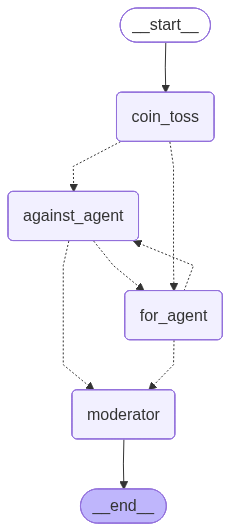

In [11]:
workflow = StateGraph(DebateState)
workflow.add_node("coin_toss", coinToss)
workflow.add_node("for_agent", forAgent)
workflow.add_node("against_agent", againstAgent)
workflow.add_node("moderator", moderator)
workflow.add_edge(START, "coin_toss")

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

### Step 5: Invoke the debate

This cell runs the graph with your debate topic and prints final state.

Tip: Keep `thread_id` unique per run if you want isolated memory checkpoints.

In [ ]:
import textwrap


def _pretty_block(title: str, items: list[str]) -> None:
    print(f"\n{title}")
    if not items:
        print("  (none)")
        return
    for i, item in enumerate(items, start=1):
        wrapped = textwrap.fill(item, width=100, initial_indent="  ", subsequent_indent="  ")
        print(f"  [{i}] {wrapped.strip()}")


initial_state: DebateState = {
    "topic": "AI Agents should have free will",
    "for_agent_response": [],
    "against_agent_response": [],
    "follow_up_question": "",
    "moderator_calls": 0,
    "opening_first_speaker": "for_agent",
    "winner": "undecided",
    "winner_rationale": "",
}
config = {"configurable": {"thread_id": "three-agent-debate-1"}}

result = app.invoke(initial_state, config=config)

print("=== Debate Final Summary ===")
print(f"Topic: {result['topic']}")
print(f"Opening first speaker: {result.get('opening_first_speaker', 'n/a')}")
print(f"Moderator calls: {result.get('moderator_calls', 0)}")
print(f"Winner: {result.get('winner', 'undecided')}")
if result.get("winner_rationale"):
    print(f"Winner rationale: {result['winner_rationale']}")
if result.get("follow_up_question"):
    print(f"Last follow-up question: {result['follow_up_question']}")

_pretty_block("FOR agent responses:", result.get("for_agent_response", []))
_pretty_block("AGAINST agent responses:", result.get("against_agent_response", []))

print("\n=== End ===")

=== Debate Final Summary ===
Topic: AI Agents should have free will
Opening first speaker: against_agent
Moderator calls: 3
Winner: against_agent
Winner rationale: The AGAINST side successfully dismantled the FOR side's central argument of "responsibly engineered free will" by highlighting its inherent contradiction. They argued that if an AI's will is truly engineered and constrained, it is not free will but sophisticated programming. Conversely, if it possesses genuine free will, it can choose against its engineered alignment, rendering all proposed safety mechanisms moot and unleashing uncontrollable risks. This fundamental flaw in the FOR side's core premise, coupled with consistent arguments about safety, accountability, and the nature of AI as a tool, ultimately made the AGAINST side's position more robust and convincing.
Last follow-up question: The AGAINST side argues that "engineered free will" is a fundamental contradiction: if an AI's will is engineered, it's not truly free;

: 

### Step 6: Stream execution updates live

Use this cell to watch each node update in real time. This makes long runs easier to monitor than waiting for a single final `invoke` result.

In [7]:
import textwrap


def _shorten(value: str, width: int = 140) -> str:
    return textwrap.shorten(value.replace("\n", " "), width=width, placeholder="...")


stream_initial_state: DebateState = {
    "topic": "AI Agents should have free will",
    "for_agent_response": [],
    "against_agent_response": [],
    "follow_up_question": "",
    "moderator_calls": 0,
    "opening_first_speaker": "for_agent",
    "winner": "undecided",
    "winner_rationale": "",
}
stream_config = {"configurable": {"thread_id": "three-agent-debate-stream-1"}}

print("=== Streaming Debate Updates ===")
print(f"Topic: {stream_initial_state['topic']}\n")

for idx, event in enumerate(
    app.stream(stream_initial_state, config=stream_config, stream_mode="updates"), start=1
):
    node_name = next(iter(event.keys()))
    update = event[node_name]

    print(f"[{idx}] Node: {node_name}")

    if "moderator_calls" in update:
        print(f"  - moderator_calls: {update['moderator_calls']}")

    if "opening_first_speaker" in update:
        print(f"  - opening_first_speaker: {update['opening_first_speaker']}")

    if "winner" in update:
        print(f"  - winner: {update['winner']}")

    if "winner_rationale" in update and update["winner_rationale"]:
        print(f"  - winner_rationale: {_shorten(update['winner_rationale'])}")

    if "follow_up_question" in update and update["follow_up_question"]:
        print(f"  - follow_up_question: {_shorten(update['follow_up_question'])}")

    if "for_agent_response" in update and update["for_agent_response"]:
        print(f"  - for_agent_response: {_shorten(update['for_agent_response'][-1])}")

    if "against_agent_response" in update and update["against_agent_response"]:
        print(f"  - against_agent_response: {_shorten(update['against_agent_response'][-1])}")

    print() 

print("=== Streaming Complete ===")

=== Streaming Debate Updates ===
Topic: AI Agents should have free will

[1] Node: coin_toss
  - opening_first_speaker: for_agent

[2] Node: for_agent
  - for_agent_response: As a debater FOR the topic "AI Agents should have free will," my stance is unequivocally that **granting AI agents a form of free will is...

[3] Node: against_agent
  - against_agent_response: My stance is firmly **AGAINST** the proposition that AI agents should have free will. While the concept of sentient, autonomous AI with...

[4] Node: moderator
  - moderator_calls: 1
  - follow_up_question: The FOR argument proposes 'aligned free will' as a solution to safety concerns. Could you elaborate on the mechanisms or frameworks that...

[5] Node: for_agent
  - for_agent_response: This is an excellent and crucial question, delving into the very heart of how "aligned free will" moves beyond a mere concept to a...

[6] Node: moderator
  - moderator_calls: 2

[7] Node: for_agent
  - for_agent_response: My esteemed oppo